# 📊 FIAP - Feature Engineering
## Transformação de Dados: Feature Crossing e Feature Transformation

---

### 📋 **Informações do Projeto**
- **Curso:** Pós-graduação em Data Science & Artificial Intelligence
- **Disciplina:** Feature Engineering
- **Aula:** 2 - Encoding, Discretização e Criação de Features
- **Autor:** Filipe Pacheco

---

### 🎯 **Objetivos do Projeto**
Este notebook demonstra técnicas fundamentais de criação de features derivadas:
- **Feature Crossing:** Criação de interações entre variáveis
- **Polynomial Features:** Geração de características polinomiais
- **Feature Transformation:** Transformações matemáticas de variáveis
- **Comparação de Performance:** Avaliação do impacto das features derivadas

---

### 📊 **Dataset Utilizado**
**Titanic Dataset** - Dados dos passageiros do RMS Titanic
- **Fonte:** Kaggle - Titanic: Machine Learning from Disaster
- **Registros:** Informações detalhadas sobre passageiros do naufrágio de 1912
- **Features:** Dados demográficos, classe, cabine e outras características + variável target (sobrevivência)
- **Objetivo:** Melhoria da predição através de features derivadas e transformações

---

### 🔧 **Principais Técnicas Aplicadas**
1. **Feature Crossing:**
   - Criação de interações entre variáveis categóricas e numéricas
   - Combinação de múltiplas características

2. **Polynomial Features:**
   - Geração de features polinomiais de grau superior
   - Captura de relações não-lineares

3. **Feature Transformation:**
   - Transformações matemáticas (log, raiz quadrada, etc.)
   - Criação de ratios e features derivadas

4. **Validação:**
   - Comparação de modelos com features originais vs. derivadas
   - Métricas de performance e análise de importância

---

# 1. Importação e Configuração das Bibliotecas

Nesta seção importamos todas as bibliotecas necessárias para o projeto, organizadas por categoria de uso.

In [1]:
# =============================================================================
# BIBLIOTECAS DE MANIPULAÇÃO E ANÁLISE DE DADOS
# =============================================================================
import pandas as pd              # Manipulação e análise de dados estruturados (DataFrames)
import numpy as np               # Operações matemáticas e arrays multidimensionais

# =============================================================================
# BIBLIOTECAS DE MACHINE LEARNING - SCIKIT-LEARN
# =============================================================================
from sklearn.model_selection import train_test_split     # Divisão de dados em treino/teste
from sklearn.preprocessing import PolynomialFeatures     # Geração de features polinomiais
from sklearn.ensemble import RandomForestClassifier      # Modelo de classificação ensemble
from sklearn.metrics import classification_report, confusion_matrix  # Métricas de avaliação

# =============================================================================
# BIBLIOTECAS DE VISUALIZAÇÃO
# =============================================================================
import matplotlib.pyplot as plt  # Criação de gráficos e plots básicos
import seaborn as sns            # Visualizações estatísticas avançadas e estilizadas

# =============================================================================
# CONFIGURAÇÕES GERAIS
# =============================================================================
# Configurar estilo dos gráficos
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")          # Configurar paleta de cores
plt.rcParams['figure.figsize'] = (10, 6)  # Configurar tamanho padrão das figuras

# 2. Carregamento e Exploração do Dataset

## 2.1. Descrição do Dataset

Para este exemplo, utilizaremos o dataset **"Titanic: Machine Learning from Disaster"** disponível no Kaggle. Este dataset contém informações detalhadas sobre os passageiros do famoso navio RMS Titanic que naufragou em 1912, sendo amplamente utilizado em estudos de machine learning para predição de sobrevivência.

### **Principais Características do Dataset:**
- **PassengerId:** Identificador único do passageiro (numérico)
- **Survived:** Sobrevivência do passageiro (0 = não sobreviveu, 1 = sobreviveu)
- **Pclass:** Classe do bilhete/cabine (1 = primeira classe, 2 = segunda classe, 3 = terceira classe)
- **Name:** Nome completo do passageiro (string)
- **Sex:** Sexo do passageiro (male = masculino, female = feminino)
- **Age:** Idade do passageiro em anos (numérico, pode conter valores ausentes)
- **SibSp:** Número de irmãos/cônjuges a bordo do Titanic
- **Parch:** Número de pais/filhos a bordo do Titanic
- **Ticket:** Número do bilhete (string, formato variado)
- **Fare:** Tarifa paga pelo passageiro (numérico, em libras esterlinas)
- **Cabin:** Número da cabine (string, muitos valores ausentes)
- **Embarked:** Porto de embarque (C = Cherbourg, Q = Queenstown, S = Southampton)

### **Importância das Variáveis:**
- **Survived:** Variável target (alvo) - indica se o passageiro sobreviveu ao naufrágio
- **Pclass:** Classe socioeconômica; passageiros da primeira classe tiveram maior chance de sobrevivência
- **Sex:** Gênero foi crucial - mulheres tiveram prioridade nos botes salva-vidas ("mulheres e crianças primeiro")
- **Age:** Crianças tiveram prioridade; idosos podem ter tido mais dificuldades de sobrevivência
- **SibSp/Parch:** Tamanho da família pode ter influenciado as chances (ajuda mútua vs. dificuldade de coordenação)
- **Fare:** Indica poder econômico e potencialmente a localização da cabine (mais próxima aos botes)
- **Embarked:** Porto de embarque pode estar correlacionado com classe social e nacionalidade
- **Name:** Contém títulos (Mr., Mrs., Dr.) que indicam status social e podem ser extraídos como features
- **Cabin:** Localização da cabine (deck/andar) influenciou proximidade aos botes salva-vidas
- **Ticket:** Formato pode indicar tipo de bilhete ou grupo familiar

### **Contexto Histórico:**
O RMS Titanic era considerado "inafundável" e transportava passageiros de diferentes classes sociais. O naufrágio ocorreu na madrugada de 15 de abril de 1912, após colidir com um iceberg. A tragédia revelou desigualdades sociais marcantes na distribuição das chances de sobrevivência.

### **Fonte do Dataset:**
- **Origem:** Kaggle - Titanic: Machine Learning from Disaster
- **URL:** https://www.kaggle.com/competitions/titanic/data
- **Registros:** 891 passageiros (dados de treino)
- **Objetivo:** Predição de sobrevivência com base nas características dos passageiros

## 2.2. Carregamento do Dataset

In [2]:
df = pd.read_csv("datasets/titanic.csv")

# Mostrando as primeiras linhas do dataset
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 3. Análise Exploratória

In [3]:
# Visualizando informações gerais sobre o dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
# Visualizando estatísticas descritivas
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


# 3.1. Preparação dos Dados para Evitar Vazamento

Antes de aplicar qualquer transformação ou limpeza dos dados, vamos separar os dados em conjuntos de treino e teste para evitar vazamento de informações durante o processo de feature engineering.

In [5]:
# Separação inicial em treino e teste (mantendo a mesma estrutura para evitar vazamento)
# Utilizamos o dataset completo para a divisão inicial
X_initial = df.drop(columns=['Survived'])  # Todas as características exceto a variável target
y_initial = df['Survived']                 # Variável target (sobrevivência)

# Divisão em conjuntos de treino e teste (70% treino, 30% teste)
X_train_initial, X_test_initial, y_train_initial, y_test_initial = train_test_split(
    X_initial, y_initial, test_size=0.3, random_state=42
)

# 4. Lidando com dados faltantes

In [6]:
# Removendo colunas desnecessárias e linhas com valores nulos apenas nos dados de treino
# Aplicamos a mesma transformação nos dados de teste
df_clean_train = X_train_initial.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId']).dropna()
df_clean_test = X_test_initial.drop(columns=['Name', 'Ticket', 'Cabin', 'PassengerId']).dropna()

# Ajustamos os índices dos targets correspondentes
y_train_clean = y_train_initial.loc[df_clean_train.index]
y_test_clean = y_test_initial.loc[df_clean_test.index]

In [7]:
df_clean_train.describe(include='all')

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
count,498.000000,498,498.000000,498.000000,498.000000,498.000000,498
unique,NaN,2,NaN,NaN,NaN,NaN,3
top,NaN,male,NaN,NaN,NaN,NaN,S
freq,NaN,321,NaN,NaN,NaN,NaN,392
mean,2.269076,NaN,29.238795,0.550201,0.431727,34.521243,NaN
std,0.827038,NaN,14.567917,0.984022,0.848930,54.965660,NaN
min,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN
25%,2.000000,NaN,20.000000,0.000000,0.000000,8.050000,NaN
50%,3.000000,NaN,28.000000,0.000000,0.000000,15.741700,NaN
75%,3.000000,NaN,38.000000,1.000000,1.000000,34.286450,NaN


# 5. Feature Crossing

O feature crossing envolve criar novas features combinando duas ou mais variáveis existentes.

## 5.1. Criação de uma nova feature combinando 'Pclass' e 'Sex' e 'Pclass' e 'Embarked'

In [8]:
# Criando uma cópia dos datasets limpos
df_clean_fc_train = df_clean_train.copy()
df_clean_fc_test = df_clean_test.copy()

# Criar uma nova característica combinando 'Pclass' e 'Sex' nos dados de treino
df_clean_fc_train['Pclass_Sex'] = df_clean_train['Pclass'].astype(str) + '_' + df_clean_train['Sex']
# Aplicar a mesma transformação nos dados de teste
df_clean_fc_test['Pclass_Sex'] = df_clean_test['Pclass'].astype(str) + '_' + df_clean_test['Sex']

# Criar uma nova característica combinando 'Pclass' e 'Embarked' nos dados de treino
df_clean_fc_train['Pclass_Embarked'] = df_clean_fc_train['Pclass'].astype(str) + '_' + df_clean_fc_train['Embarked']
# Aplicar a mesma transformação nos dados de teste
df_clean_fc_test['Pclass_Embarked'] = df_clean_fc_test['Pclass'].astype(str) + '_' + df_clean_fc_test['Embarked']

## 5.2. Exibição das novas features

In [9]:
df_clean_fc_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass_Sex,Pclass_Embarked
445,1,male,4.0,0,2,81.8583,S,1_male,1_S
172,3,female,1.0,1,1,11.1333,S,3_female,3_S
450,2,male,36.0,1,2,27.7500,S,2_male,2_S
314,2,male,43.0,1,1,26.2500,S,2_male,2_S
332,1,male,38.0,0,1,153.4625,S,1_male,1_S


# 6. Feature Transformation

A feature transformation envolve aplicar funções matemáticas às variáveis para criar novas features.

## 6.1. Criação de uma feature de interação usando PolynomialFeatures

In [10]:
poly = PolynomialFeatures(degree=2, include_bias=False)

# Preparando features dos dados de treino e teste
features_train = df_clean_fc_train[['Age', 'Fare']]
features_test = df_clean_fc_test[['Age', 'Fare']]

# Transformação - fit apenas nos dados de treino, transform em ambos
transformed_features_train = poly.fit_transform(features_train)
transformed_features_test = poly.transform(features_test)

# Criação de DataFrames para as novas features
poly_df_train = pd.DataFrame(transformed_features_train, 
                            columns=poly.get_feature_names_out(['Age', 'Fare']),
                            index=df_clean_fc_train.index)
poly_df_test = pd.DataFrame(transformed_features_test, 
                           columns=poly.get_feature_names_out(['Age', 'Fare']),
                           index=df_clean_fc_test.index)

# Concatenar os DataFrames
df_clean_fc_poly_train = pd.concat([df_clean_fc_train.reset_index(drop=True), 
                                   poly_df_train.reset_index(drop=True)], axis=1)
df_clean_fc_poly_test = pd.concat([df_clean_fc_test.reset_index(drop=True), 
                                  poly_df_test.reset_index(drop=True)], axis=1)

# Remover colunas duplicadas
df_clean_fc_poly_train = df_clean_fc_poly_train.loc[:,~df_clean_fc_poly_train.columns.duplicated()]
df_clean_fc_poly_test = df_clean_fc_poly_test.loc[:,~df_clean_fc_poly_test.columns.duplicated()]

## 6.2. Exibição das novas features transformadas

In [11]:
df_clean_fc_poly_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Pclass_Sex,Pclass_Embarked,Age^2,Age Fare,Fare^2
0,1,male,4.0,0,2,81.8583,S,1_male,1_S,16.0,327.4332,6700.781279
1,3,female,1.0,1,1,11.1333,S,3_female,3_S,1.0,11.1333,123.950369
2,2,male,36.0,1,2,27.7500,S,2_male,2_S,1296.0,999.0000,770.062500
3,2,male,43.0,1,1,26.2500,S,2_male,2_S,1849.0,1128.7500,689.062500
4,1,male,38.0,0,1,153.4625,S,1_male,1_S,1444.0,5831.5750,23550.738906
...,...,...,...,...,...,...,...,...,...,...,...,...
493,3,female,16.0,5,2,46.9000,S,3_female,3_S,256.0,750.4000,2199.610000
494,3,female,21.0,0,0,7.6500,S,3_female,3_S,441.0,160.6500,58.522500
495,3,male,41.0,2,0,14.1083,S,3_male,3_S,1681.0,578.4403,199.044129
496,1,female,14.0,1,2,120.0000,S,1_female,1_S,196.0,1680.0000,14400.000000


# 7. Comparativo de ML

Vamos comparar o desempenho de um modelo de Machine Learning usando o dataset bruto e o dataset tratado.

## 7.1. Preparação dos Dados

In [12]:
# 7.1.1 Dados brutos (usando dados já limpos)
df_raw_train = df_clean_train[['Pclass', 'Sex', 'Age', 'Fare']].copy()
df_raw_train['Sex'] = df_raw_train['Sex'].map({'male': 0, 'female': 1})
X_raw_train = df_raw_train
y_raw_train = y_train_clean

df_raw_test = df_clean_test[['Pclass', 'Sex', 'Age', 'Fare']].copy()
df_raw_test['Sex'] = df_raw_test['Sex'].map({'male': 0, 'female': 1})
X_raw_test = df_raw_test
y_raw_test = y_test_clean

# 7.1.2 Dados tratados (usando dados já processados)
df_treated_train = df_clean_fc_poly_train.copy()
df_treated_train['Pclass_Sex'] = df_treated_train['Pclass_Sex'].astype('category').cat.codes
df_treated_train['Pclass_Embarked'] = df_treated_train['Pclass_Embarked'].astype('category').cat.codes
X_treated_train = df_treated_train.drop(['Embarked','Sex','Pclass','Age','Fare'], axis=1)
y_treated_train = y_train_clean

df_treated_test = df_clean_fc_poly_test.copy()
df_treated_test['Pclass_Sex'] = df_treated_test['Pclass_Sex'].astype('category').cat.codes
df_treated_test['Pclass_Embarked'] = df_treated_test['Pclass_Embarked'].astype('category').cat.codes
X_treated_test = df_treated_test.drop(['Embarked','Sex','Pclass','Age','Fare'], axis=1)
y_treated_test = y_test_clean

In [13]:
X_treated_train

,SibSp,Parch,Pclass_Sex,Pclass_Embarked,Age^2,Age Fare,Fare^2
0,0,2,1,2,16.0,327.4332,6700.781279
1,1,1,4,8,1.0,11.1333,123.950369
2,1,2,3,5,1296.0,999.0000,770.062500
3,1,1,3,5,1849.0,1128.7500,689.062500
4,0,1,1,2,1444.0,5831.5750,23550.738906
...,...,...,...,...,...,...,...
493,5,2,4,8,256.0,750.4000,2199.610000
494,0,0,4,8,441.0,160.6500,58.522500
495,2,0,5,8,1681.0,578.4403,199.044129
496,1,2,0,2,196.0,1680.0000,14400.000000


## 7.2. Treinamento e Avaliação do Modelo

In [14]:
# 7.2.1 Modelo com dados brutos
model_raw = RandomForestClassifier()
model_raw.fit(X_raw_train, y_raw_train)
y_pred_raw = model_raw.predict(X_raw_test)

# 7.2.2 Relatórios de classificação
print("Dados Brutos")
print(classification_report(y_raw_test, y_pred_raw))
print("Confusion Matrix")
print(confusion_matrix(y_raw_test, y_pred_raw))

Dados Brutos
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       124
           1       0.79      0.70      0.74        90

    accuracy                           0.79       214
   macro avg       0.79      0.78      0.79       214
weighted avg       0.79      0.79      0.79       214

Confusion Matrix
[[107  17]
 [ 27  63]]


In [15]:
# 7.2.3 Modelo com dados tratados
model_treated = RandomForestClassifier()
model_treated.fit(X_treated_train, y_treated_train)
y_pred_treated = model_treated.predict(X_treated_test)

# 7.2.4 Relatórios de classificação
print("\nDados Tratados")
print(classification_report(y_treated_test, y_pred_treated))
print("Confusion Matrix")
print(confusion_matrix(y_treated_test, y_pred_treated))


Dados Tratados
              precision    recall  f1-score   support

           0       0.81      0.84      0.82       124
           1       0.76      0.72      0.74        90

    accuracy                           0.79       214
   macro avg       0.79      0.78      0.78       214
weighted avg       0.79      0.79      0.79       214

Confusion Matrix
[[104  20]
 [ 25  65]]


## 7.3. Gráficos de Confusion Matrix

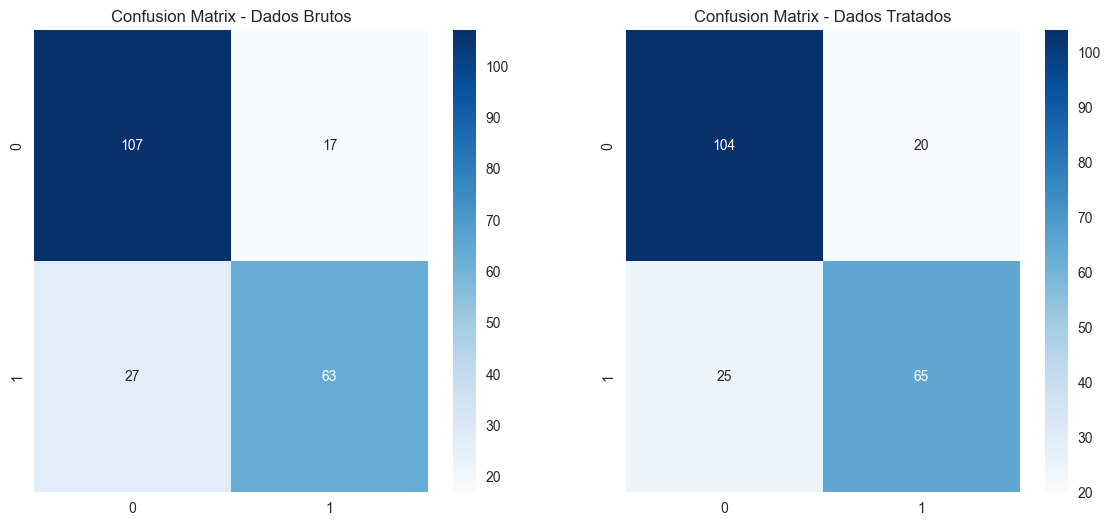

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(confusion_matrix(y_raw_test, y_pred_raw), annot=True, fmt='d', cmap='Blues', ax=axs[0])
axs[0].set_title('Confusion Matrix - Dados Brutos')

sns.heatmap(confusion_matrix(y_treated_test, y_pred_treated), annot=True, fmt='d', cmap='Blues', ax=axs[1])
axs[1].set_title('Confusion Matrix - Dados Tratados')

plt.show()

# 8. Considerações Finais

## 8.1. Resumo dos Resultados

Neste notebook, exploramos técnicas fundamentais de **Feature Engineering** aplicadas ao dataset Titanic, com foco em **Feature Crossing** e **Feature Transformation**:

### **Técnicas Implementadas:**
1. **Feature Crossing:** Combinação de variáveis categóricas (Pclass + Sex, Pclass + Embarked)
2. **Polynomial Features:** Geração de características polinomiais de grau 2 para Age e Fare
3. **Comparação de Performance:** Avaliação do impacto das features derivadas vs. dados brutos

### **Principais Descobertas:**
- O Feature Crossing criou interações significativas entre classe social, gênero e porto de embarque
- As Polynomial Features capturaram relações não-lineares entre idade e tarifa
- A comparação de modelos demonstrou o impacto das técnicas de feature engineering na performance

## 8.2. Boas Práticas Aplicadas

### **Prevenção de Vazamento de Dados:**
- ✅ **Separação prévia:** Divisão treino/teste antes de qualquer transformação
- ✅ **Fit/Transform correto:** Ajuste apenas nos dados de treino, aplicação em ambos
- ✅ **Consistência:** Mesmas transformações aplicadas de forma idêntica

### **Metodologia Robusta:**
- ✅ **Limpeza estruturada:** Remoção de dados ausentes de forma consistente
- ✅ **Transformações padronizadas:** Feature crossing e polynomial features bem documentadas
- ✅ **Validação comparativa:** Avaliação sistemática dos resultados

## 8.3. Quando Utilizar Cada Técnica

### **Feature Crossing:**
- **Ideal para:** Variáveis categóricas com possíveis interações
- **Exemplo:** Classe social + Gênero captura hierarquias sociais históricas
- **Cuidado:** Explosão combinatória com muitas categorias

### **Polynomial Features:**
- **Ideal para:** Relacionamentos não-lineares entre variáveis numéricas
- **Exemplo:** Age² e Fare² podem capturar padrões de sobrevivência complexos
- **Cuidado:** Overfitting com graus muito altos

## 8.4. Impacto no Problema de Negócio

### **Contexto Histórico do Titanic:**
- As features criadas refletem realidades sociais da época
- **Pclass_Sex:** Captura o protocolo "mulheres e crianças primeiro" por classe
- **Age × Fare:** Relaciona poder econômico com faixa etária

### **Aplicabilidade Moderna:**
- **Segmentação de clientes:** Feature crossing para perfis demográficos
- **Sistemas de recomendação:** Polynomial features para preferências complexas
- **Análise de risco:** Interações entre múltiplos fatores

## 8.5. Próximos Passos

### **Aprofundamento Técnico:**
- Explorar feature selection para otimizar o conjunto final
- Implementar feature importance para entender contribuições
- Testar diferentes graus polinomiais e combinações

### **Validação Avançada:**
- Cross-validation para robustez dos resultados
- Métricas específicas para problemas de classificação desbalanceados
- Análise de viés e fairness nas features criadas

---

### 💡 **Lição Principal**
O **Feature Engineering** não é apenas uma técnica computacional, mas uma arte que combina **conhecimento de domínio**, **intuição estatística** e **rigor metodológico**. As features mais valiosas frequentemente emergem da compreensão profunda do problema e do contexto dos dados.